# GPQR Tutoral

Gaussian process quantile regression (GPQR) estimates quantile function using Gaussian process regression.

In this tutorial, we estimate multiple quantile levels for data with heteroscadastic noise. To avoid quantile crossing, multitask center-gap architecture with informative prior is used.

In [ ]:
%config InlineBackend.figure_formats = ["svg"]

In [ ]:
import torch
import gpytorch
import matplotlib.pyplot as plt

from gpytorch_qr.mtgpqr_cg import (
    MultitaskCenterGapQuantileGP,
    CenterGapLmcVariationalStrategy,
    MultitaskCenterGapALDLikelihood,
)

torch.manual_seed(42);

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1)
x = x_range.repeat(5, 1)
y = (mean(x) + torch.randn(x.shape).mul(std(x))).squeeze()
q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9])
true_quantiles = mean(x_range) + std(x_range) * torch.distributions.Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1)

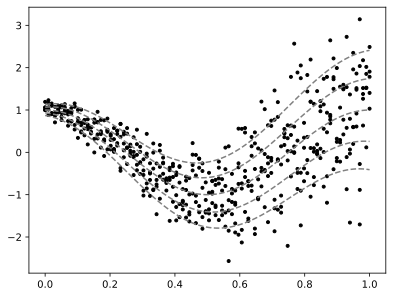

In [ ]:
plt.scatter(x, y, c="k", marker=".")
plt.plot(x_range, true_quantiles, "--", c="gray")
plt.show()

## Prior mean for central quantile

In [ ]:
class PriorMean(gpytorch.means.Mean):
    def forward(self, x):
        return mean(x).squeeze()

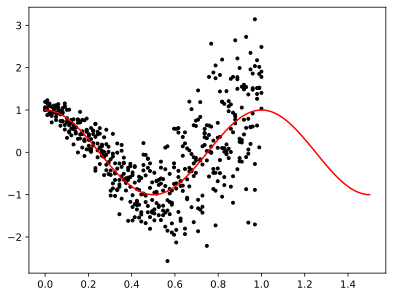

In [ ]:
plt.scatter(x, y, c="k", marker=".")
plt.plot(x_pred, PriorMean()(x_pred).detach(), c="r")
plt.show()

## Define model and likelihood

In [ ]:
class MyGP(MultitaskCenterGapQuantileGP):
    def __init__(
        self,
        inducing_points,
        num_quantiles,
        num_lower_quantiles,
        num_latents,
        num_lower_latents,
    ):
        N, D = inducing_points.size()
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_latents]),
        )
        variational_strategy = CenterGapLmcVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=True,
            ),
            num_quantiles=num_quantiles,
            num_latents=num_latents,
            num_lower_quantiles=num_lower_quantiles,
            num_lower_latents=num_lower_latents,
        )

        center_mean = PriorMean()
        gap_mean = gpytorch.means.ConstantMean(
            batch_shape=torch.Size([num_latents - 1])
        )
        covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                ard_num_dims=D, batch_shape=torch.Size([num_latents])
            ),
            batch_shape=torch.Size([num_latents]),
        )
        super().__init__(variational_strategy, center_mean, gap_mean, covar_module)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1)
central_q_index = 2
num_latents = len(q)
gp = MyGP(inducing_points, len(q), central_q_index, num_latents, num_latents // 2)
likelihood = MultitaskCenterGapALDLikelihood(q, central_q_index)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = gpytorch.mlls.VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

N = 10000
for i in range(N):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if (i + 1) % (N // 10) == 0:
        print(f"{i + 1}/{N}")

gp.eval()
with torch.no_grad():
    quantiles = gp.mean_quantiles(x_pred, central_q_index).detach()

1000/10000


2000/10000


3000/10000


4000/10000


5000/10000


6000/10000


7000/10000


8000/10000


9000/10000


10000/10000


## Plot result

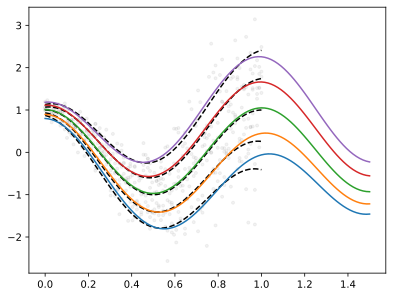

In [ ]:
plt.scatter(x, y, c="gray", marker=".", alpha=0.1)
plt.plot(x_range, true_quantiles, "--", c="k")
plt.plot(x_pred, quantiles)
plt.show()